In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from PIL import Image

In [2]:
IMAGE_PATH = "/content/Otsu_Input_16_Level.png"

print("Image path:", IMAGE_PATH)

Image path: /content/Otsu_Input_16_Level.png


In [3]:
# Load image
original_image = Image.open(IMAGE_PATH)

# Convert to grayscale
gray_image = np.array(original_image.convert("L"))

print("Image shape:", gray_image.shape)
print("Data type:", gray_image.dtype)
print("Minimum intensity:", gray_image.min())
print("Maximum intensity:", gray_image.max())

Image shape: (558, 556)
Data type: uint8
Minimum intensity: 0
Maximum intensity: 238


In [5]:
# Quantize grayscale image from 0-255 to 0-15
quantized_image = np.rint(
    gray_image.astype(np.float64) * 15 / 255
).astype(np.uint8)

print("Quantized minimum:", quantized_image.min())
print("Quantized maximum:", quantized_image.max())

print("Unique quantized levels:")
print(np.unique(quantized_image))

Quantized minimum: 0
Quantized maximum: 14
Unique quantized levels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 14]


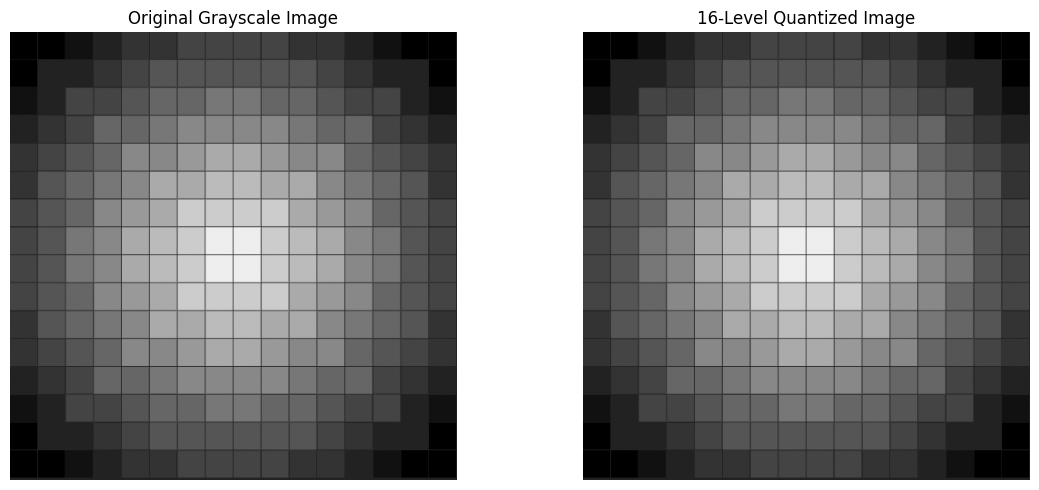

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap="gray", vmin=0, vmax=255)
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(quantized_image, cmap="gray", vmin=0, vmax=15)
plt.title("16-Level Quantized Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Count pixels for each intensity level 0-15
histogram = np.bincount(
    quantized_image.ravel(),
    minlength=16
)

# Normalize histogram
probabilities = histogram / quantized_image.size

histogram_table = pd.DataFrame({
    "Intensity": np.arange(16),
    "Pixel Count": histogram,
    "Probability p(i)": probabilities
})

histogram_table

,Intensity,Pixel Count,Probability p(i)
0,0,13600,0.043836
1,1,9656,0.031123
2,2,31012,0.099959
3,3,34870,0.112394
4,4,43586,0.140488
5,5,37478,0.120800
6,6,32236,0.103904
7,7,18957,0.061103
8,8,31296,0.100874
9,9,9241,0.029786


In [9]:
print("Sum of probabilities:", probabilities.sum())

assert np.isclose(probabilities.sum(), 1.0)

print("Histogram probability check: PASSED")

Sum of probabilities: 1.0
Histogram probability check: PASSED


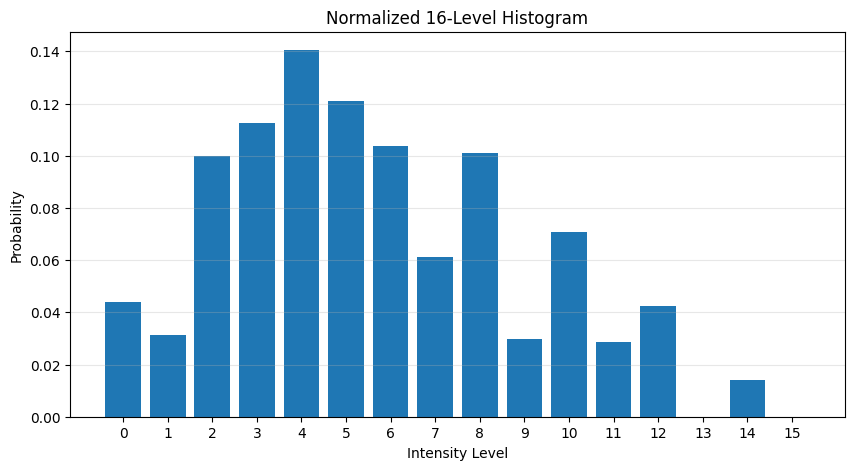

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(
    np.arange(16),
    probabilities
)

plt.xticks(np.arange(16))
plt.xlabel("Intensity Level")
plt.ylabel("Probability")
plt.title("Normalized 16-Level Histogram")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [11]:
levels = np.arange(16)

global_mean = np.sum(levels * probabilities)

print("Global Mean =", global_mean)

Global Mean = 5.587494520512623


In [12]:
# Store results for every threshold
results = []

for T in range(16):

    # --------------------------------------------------------
    # Background: intensity <= T
    # Foreground: intensity > T
    # --------------------------------------------------------

    background_mask = levels <= T
    foreground_mask = levels > T

    # Class probabilities / weights
    w1 = np.sum(probabilities[background_mask])
    w2 = np.sum(probabilities[foreground_mask])

    # --------------------------------------------------------
    # Background mean
    # --------------------------------------------------------

    if w1 > 0:
        mu1 = np.sum(
            levels[background_mask] * probabilities[background_mask]
        ) / w1
    else:
        mu1 = 0

    # --------------------------------------------------------
    # Foreground mean
    # --------------------------------------------------------

    if w2 > 0:
        mu2 = np.sum(
            levels[foreground_mask] * probabilities[foreground_mask]
        ) / w2
    else:
        mu2 = 0

    # --------------------------------------------------------
    # Background variance
    # --------------------------------------------------------

    if w1 > 0:
        sigma1_squared = np.sum(
            probabilities[background_mask] *
            (levels[background_mask] - mu1) ** 2
        ) / w1
    else:
        sigma1_squared = 0

    # --------------------------------------------------------
    # Foreground variance
    # --------------------------------------------------------

    if w2 > 0:
        sigma2_squared = np.sum(
            probabilities[foreground_mask] *
            (levels[foreground_mask] - mu2) ** 2
        ) / w2
    else:
        sigma2_squared = 0

    # --------------------------------------------------------
    # Within-class variance
    # sigma_W^2 = w1*sigma1^2 + w2*sigma2^2
    # --------------------------------------------------------

    sigma_W_squared = (
        w1 * sigma1_squared +
        w2 * sigma2_squared
    )

    # --------------------------------------------------------
    # Between-class variance
    # sigma_B^2 = w1*w2*(mu1-mu2)^2
    # --------------------------------------------------------

    sigma_B_squared = (
        w1 * w2 * (mu1 - mu2) ** 2
    )

    results.append([
        T,
        w1,
        w2,
        mu1,
        mu2,
        sigma1_squared,
        sigma2_squared,
        sigma_W_squared,
        sigma_B_squared
    ])

In [13]:
otsu_table = pd.DataFrame(
    results,
    columns=[
        "Threshold T",
        "Background Weight w1",
        "Foreground Weight w2",
        "Background Mean μ1",
        "Foreground Mean μ2",
        "Background Variance σ1²",
        "Foreground Variance σ2²",
        "Within-Class Variance σW²",
        "Between-Class Variance σB²"
    ]
)

otsu_table

,Threshold T,Background Weight w1,Foreground Weight w2,Background Mean μ1,Foreground Mean μ2,Background Variance σ1²,Foreground Variance σ2²,Within-Class Variance σW²,Between-Class Variance σB²
0,0,0.043836,0.956164,0.000000,5.843656,0.000000,9.469438,9.054337,1.431303
1,1,0.074959,0.925041,0.415205,6.006624,0.242810,8.972126,8.317782,2.167859
2,2,0.174918,0.825082,1.320852,6.492027,0.719122,7.878657,6.626325,3.859315
3,3,0.287312,0.712688,1.977720,7.042734,1.109311,6.894791,5.232553,5.253088
4,4,0.427800,0.572200,2.641828,7.789792,1.646991,5.756420,3.998407,6.487233
5,5,0.548600,0.451400,3.161091,8.536374,2.239205,4.656714,3.330469,7.155171
6,6,0.652504,0.347496,3.613156,9.294769,2.961645,3.550371,3.166225,7.319415
7,7,0.713607,0.286393,3.903155,9.784363,3.606136,2.944643,3.416689,7.068951
8,8,0.814481,0.185519,4.410553,10.754591,4.980791,1.873180,4.404269,6.081371
9,9,0.844267,0.155733,4.572469,11.090177,5.521958,1.530013,4.900278,5.585362


In [15]:
optimal_index = otsu_table["Between-Class Variance σB²"].idxmax()

optimal_threshold = int(
    otsu_table.loc[optimal_index, "Threshold T"]
)

maximum_between_variance = (
    otsu_table.loc[
        optimal_index,
        "Between-Class Variance σB²"
    ]
)

print("Optimal Threshold T* =", optimal_threshold)
print("Maximum σB² =", maximum_between_variance)

Optimal Threshold T* = 6
Maximum σB² = 7.319415331754345


#Find Minimum Within-Class Variance

Otsu is also equivalent to minimizing:

$$ \sigma_W^2(T) $$

In [16]:
minimum_index = otsu_table["Within-Class Variance σW²"].idxmin()

minimum_within_variance_threshold = int(
    otsu_table.loc[
        minimum_index,
        "Threshold T"
    ]
)

minimum_within_variance = (
    otsu_table.loc[
        minimum_index,
        "Within-Class Variance σW²"
    ]
)

print(
    "Threshold with minimum σW² =",
    minimum_within_variance_threshold
)

print(
    "Minimum σW² =",
    minimum_within_variance
)

Threshold with minimum σW² = 6
Minimum σW² = 3.1662250631577376


In [17]:
thresholds_agree = (
    optimal_threshold ==
    minimum_within_variance_threshold
)

print("Optimal threshold from maximum σB²:", optimal_threshold)
print("Optimal threshold from minimum σW²:", minimum_within_variance_threshold)

print(
    "Do both criteria agree?",
    thresholds_agree
)

Optimal threshold from maximum σB²: 6
Optimal threshold from minimum σW²: 6
Do both criteria agree? True


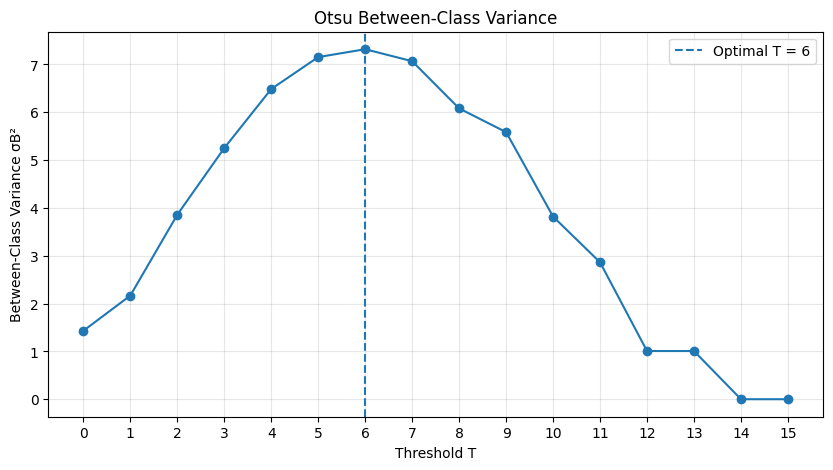

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    otsu_table["Threshold T"],
    otsu_table["Between-Class Variance σB²"],
    marker="o"
)

plt.axvline(
    optimal_threshold,
    linestyle="--",
    label=f"Optimal T = {optimal_threshold}"
)

plt.xlabel("Threshold T")
plt.ylabel("Between-Class Variance σB²")
plt.title("Otsu Between-Class Variance")

plt.xticks(range(16))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

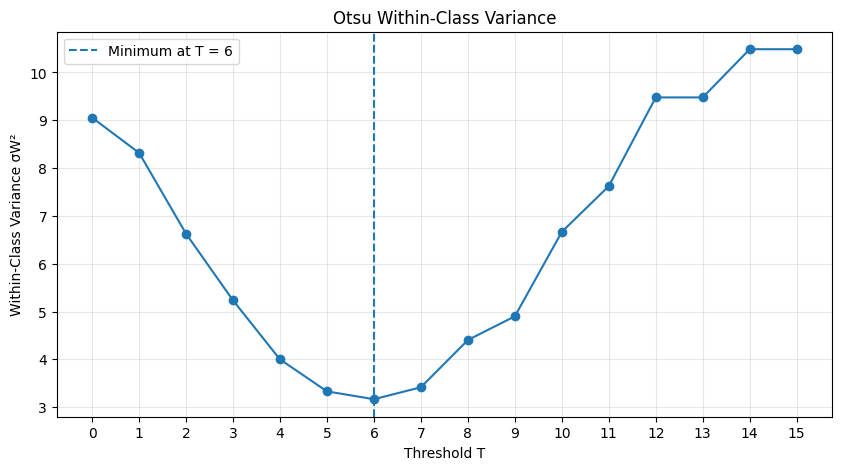

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    otsu_table["Threshold T"],
    otsu_table["Within-Class Variance σW²"],
    marker="o"
)

plt.axvline(
    minimum_within_variance_threshold,
    linestyle="--",
    label=f"Minimum at T = {minimum_within_variance_threshold}"
)

plt.xlabel("Threshold T")
plt.ylabel("Within-Class Variance σW²")
plt.title("Otsu Within-Class Variance")

plt.xticks(range(16))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

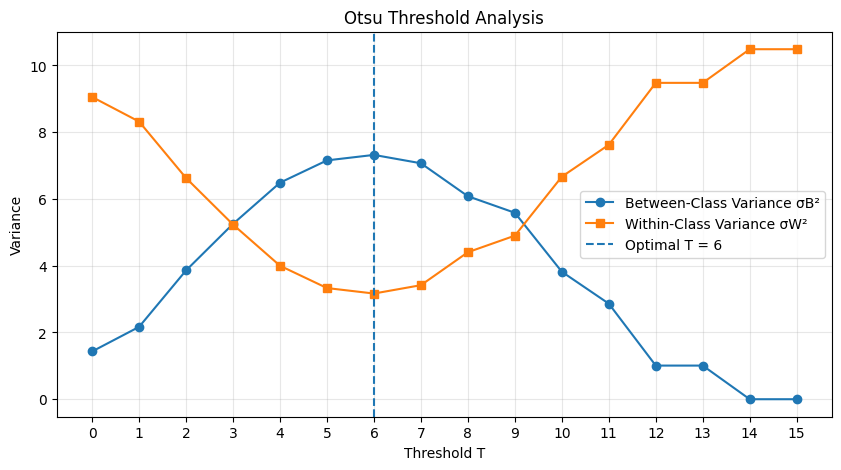

In [49]:
# ============================================================
# Otsu Variance Analysis
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    otsu_table["Threshold T"],
    otsu_table["Between-Class Variance σB²"],
    marker="o",
    label="Between-Class Variance σB²"
)

plt.plot(
    otsu_table["Threshold T"],
    otsu_table["Within-Class Variance σW²"],
    marker="s",
    label="Within-Class Variance σW²"
)

plt.axvline(
    optimal_threshold,
    linestyle="--",
    label=f"Optimal T = {optimal_threshold}"
)

plt.xlabel("Threshold T")
plt.ylabel("Variance")
plt.title("Otsu Threshold Analysis")
plt.xticks(range(16))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#Segment Image Using Custom Otsu Threshold

The assignment specifically gives:

$$ g(x,y)= \begin{cases} 1 & f(x,y)>T^*\\ 0 & \text{otherwise} \end{cases} $$

In [20]:
custom_binary = (
    quantized_image > optimal_threshold
).astype(np.uint8)

print("Custom binary unique values:")
print(np.unique(custom_binary))

Custom binary unique values:
[0 1]


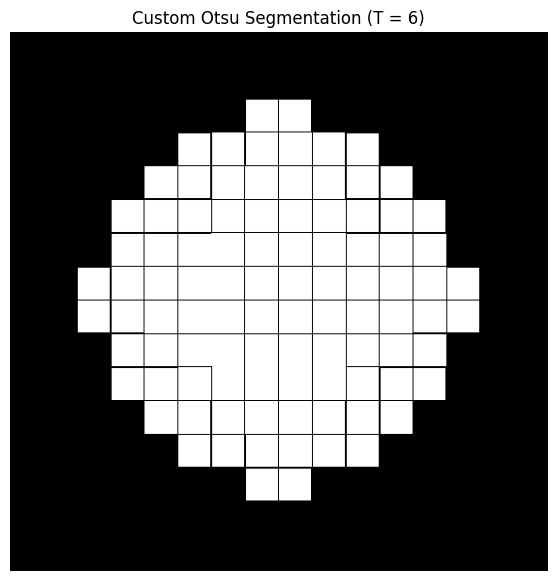

In [21]:
plt.figure(figsize=(7, 7))

plt.imshow(
    custom_binary,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    f"Custom Otsu Segmentation (T = {optimal_threshold})"
)

plt.axis("off")

plt.show()

Count Background and Foreground Pixels

In [22]:
background_pixels = np.sum(custom_binary == 0)
foreground_pixels = np.sum(custom_binary == 1)

total_pixels = custom_binary.size

print("Total pixels:", total_pixels)
print("Background pixels:", background_pixels)
print("Foreground pixels:", foreground_pixels)

print(
    "Background percentage:",
    background_pixels / total_pixels * 100
)

print(
    "Foreground percentage:",
    foreground_pixels / total_pixels * 100
)

Total pixels: 310248
Background pixels: 202438
Foreground pixels: 107810
Background percentage: 65.25038034088858
Foreground percentage: 34.74961965911142


compare our implementation against OpenCV

In [23]:
opencv_threshold, opencv_binary = cv2.threshold(
    quantized_image,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("OpenCV Otsu threshold =", opencv_threshold)

OpenCV Otsu threshold = 6.0


In [24]:
opencv_binary_01 = (
    opencv_binary > 0
).astype(np.uint8)

print("OpenCV binary unique values:")
print(np.unique(opencv_binary_01))

OpenCV binary unique values:
[0 1]


Compare Custom Threshold and Library Threshold

In [25]:
print("Custom Otsu threshold :", optimal_threshold)
print("OpenCV Otsu threshold :", opencv_threshold)

threshold_match = (
    optimal_threshold == int(opencv_threshold)
)

print("Threshold exact match:", threshold_match)

Custom Otsu threshold : 6
OpenCV Otsu threshold : 6.0
Threshold exact match: True


Exact Binary Image Match

In [26]:
exact_pixel_match = np.array_equal(
    custom_binary,
    opencv_binary_01
)

print("Exact binary output match:", exact_pixel_match)

Exact binary output match: True


Calculate Percentage of Matching Pixels

    Percentage of matching pixels between custom and library binary outputs

In [27]:
matching_pixels = np.sum(
    custom_binary == opencv_binary_01
)

total_pixels = custom_binary.size

matching_percentage = (
    matching_pixels / total_pixels
) * 100

print("Matching pixels:", matching_pixels)
print("Total pixels:", total_pixels)
print(
    f"Matching pixel percentage: {matching_percentage:.2f}%"
)

Matching pixels: 310248
Total pixels: 310248
Matching pixel percentage: 100.00%


Display Custom vs OpenCV Results

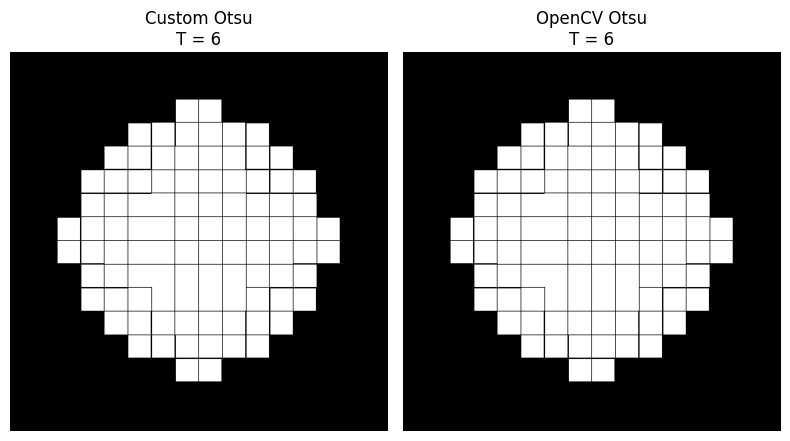

In [48]:
plt.figure(figsize=(8, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    custom_binary,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    f"Custom Otsu\nT = {optimal_threshold}"
)

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    opencv_binary_01,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    f"OpenCV Otsu\nT = {int(opencv_threshold)}"
)

plt.axis("off")

plt.tight_layout()
plt.show()

Final Comparison Summary

In [34]:
# Highlight the row corresponding to the optimal threshold

otsu_table.style.apply(
    lambda row: [
        "background-color: lightgreen"
        if row["Threshold T"] == optimal_threshold
        else ""
        for _ in row
    ],
    axis=1
)

,Threshold T,Background Weight w1,Foreground Weight w2,Background Mean μ1,Foreground Mean μ2,Background Variance σ1²,Foreground Variance σ2²,Within-Class Variance σW²,Between-Class Variance σB²
0,0,0.043836,0.956164,0.000000,5.843656,0.000000,9.469438,9.054337,1.431303
1,1,0.074959,0.925041,0.415205,6.006624,0.242810,8.972126,8.317782,2.167859
2,2,0.174918,0.825082,1.320852,6.492027,0.719122,7.878657,6.626325,3.859315
3,3,0.287312,0.712688,1.977720,7.042734,1.109311,6.894791,5.232553,5.253088
4,4,0.427800,0.572200,2.641828,7.789792,1.646991,5.756420,3.998407,6.487233
5,5,0.548600,0.451400,3.161091,8.536374,2.239205,4.656714,3.330469,7.155171
6,6,0.652504,0.347496,3.613156,9.294769,2.961645,3.550371,3.166225,7.319415
7,7,0.713607,0.286393,3.903155,9.784363,3.606136,2.944643,3.416689,7.068951
8,8,0.814481,0.185519,4.410553,10.754591,4.980791,1.873180,4.404269,6.081371
9,9,0.844267,0.155733,4.572469,11.090177,5.521958,1.530013,4.900278,5.585362


In [30]:
comparison_results = pd.DataFrame({
    "Metric": [
        "Custom Otsu Threshold",
        "OpenCV Otsu Threshold",
        "Threshold Exact Match",
        "Binary Output Exact Match",
        "Matching Pixel Percentage"
    ],

    "Result": [
        optimal_threshold,
        int(opencv_threshold),
        threshold_match,
        exact_pixel_match,
        f"{matching_percentage:.2f}%"
    ]
})

comparison_results

,Metric,Result
0,Custom Otsu Threshold,6
1,OpenCV Otsu Threshold,6
2,Threshold Exact Match,True
3,Binary Output Exact Match,True
4,Matching Pixel Percentage,100.00%


# Question 2

    Intensity Transformations for Enhancement

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
IMAGE_PATH = "/content/Chest_Xray.png"

image = Image.open(IMAGE_PATH).convert("L")

gray_image = np.array(image)

print("Image shape:", gray_image.shape)
print("Data type:", gray_image.dtype)

Image shape: (1024, 1024)
Data type: uint8


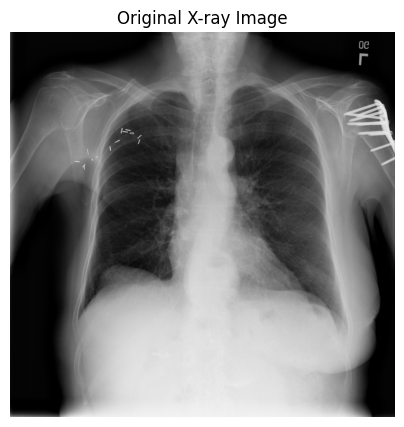

In [5]:
plt.figure(figsize=(5, 5))

plt.imshow(
    gray_image,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("Original X-ray Image")
plt.axis("off")

plt.show()

Original Histogram and Statistics

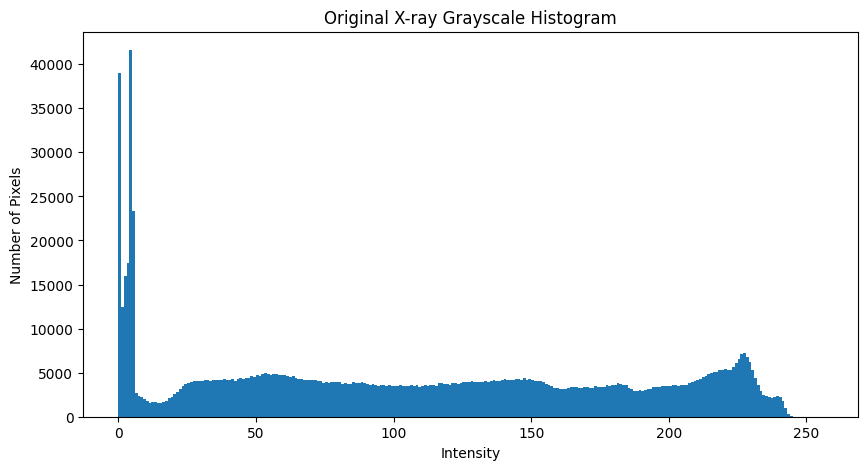

In [6]:
plt.figure(figsize=(10, 5))

plt.hist(
    gray_image.ravel(),
    bins=256,
    range=(0, 256)
)

plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Original X-ray Grayscale Histogram")

plt.show()

Calculate Required Statistics

    Minimum
    Maximum
    Mean
    Standard deviation

In [7]:
minimum_intensity = np.min(gray_image)
maximum_intensity = np.max(gray_image)
mean_intensity = np.mean(gray_image)
std_intensity = np.std(gray_image)

print("Minimum intensity       :", minimum_intensity)
print("Maximum intensity       :", maximum_intensity)
print("Mean intensity          :", mean_intensity)
print("Standard deviation      :", std_intensity)

Minimum intensity       : 0
Maximum intensity       : 248
Mean intensity          : 108.64336967468262
Standard deviation      : 75.8531358608984


In [8]:
original_statistics = pd.DataFrame({
    "Metric": [
        "Minimum Intensity",
        "Maximum Intensity",
        "Mean Intensity",
        "Standard Deviation"
    ],

    "Value": [
        minimum_intensity,
        maximum_intensity,
        mean_intensity,
        std_intensity
    ]
})

original_statistics

,Metric,Value
0,Minimum Intensity,0.000000
1,Maximum Intensity,248.000000
2,Mean Intensity,108.643370
3,Standard Deviation,75.853136


Normalize Image

For the transformations, it is much cleaner to work with:

$$ r=\frac{f(x,y)}{L-1} $$

where \(L=256\).

Therefore:

$$ r\in[0,1] $$

In [9]:
L = 256

normalized_image = gray_image.astype(np.float64) / (L - 1)

print("Normalized minimum:", normalized_image.min())
print("Normalized maximum:", normalized_image.max())

Normalized minimum: 0.0
Normalized maximum: 0.9725490196078431


Logarithmic Transformation

The transformation from the graph is:

$$ s=c\log(1+r) $$

For normalization to [0,1]:

$$ c=\frac{1}{\log(2)} $$

Therefore:

$$ s=\frac{\log(1+r)}{\log(2)} $$

In [10]:
# ============================================================
# Logarithmic Transformation
# s = log(1+r) / log(2)
# ============================================================

log_image = np.log1p(normalized_image) / np.log(2)

# Convert back to 8-bit
log_image_uint8 = np.clip(
    log_image * 255,
    0,
    255
).astype(np.uint8)

print("Log transformation completed.")

Log transformation completed.


Display Log-Transformed Image

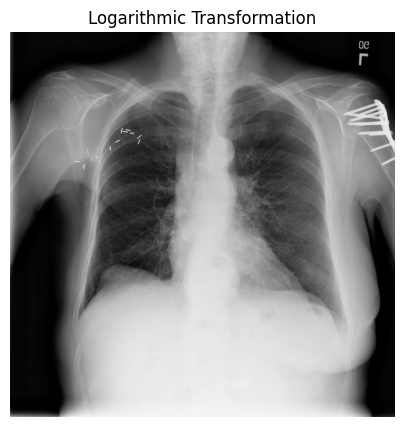

In [11]:
plt.figure(figsize=(8, 5))

plt.imshow(
    log_image_uint8,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("Logarithmic Transformation")
plt.axis("off")

plt.show()

Log Transformation Histogram

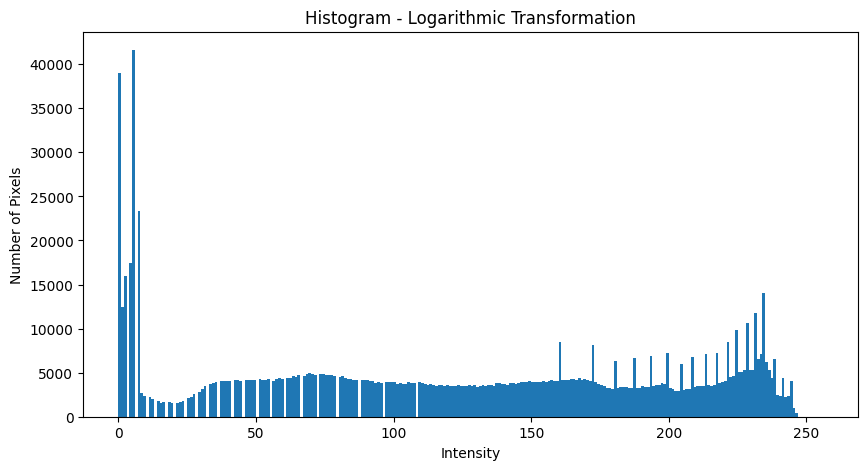

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(
    log_image_uint8.ravel(),
    bins=256,
    range=(0, 256)
)

plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Histogram - Logarithmic Transformation")

plt.show()

Power-Law Transformations

The power-law transformation is:

$$ s=cr^\gamma $$

Since \(r\) is normalized to [0,1], we can use:

$$ s=r^\gamma $$

We'll test multiple gamma values:

γ=0.4,0.6,1.0,1.5,2.0

In [13]:
gamma_values = [
    0.4,
    0.6,
    1.0,
    1.5,
    2.0
]

print("Gamma values:", gamma_values)

Gamma values: [0.4, 0.6, 1.0, 1.5, 2.0]


Implement Power-Law Transformation

In [17]:
# ============================================================
# Power-Law Transformations
# s = r^gamma
# ============================================================

power_images = {}

for gamma in gamma_values:

    transformed = normalized_image ** gamma

    transformed_uint8 = np.clip(
        transformed * 255,
        0,
        255
    ).astype(np.uint8)

    power_images[gamma] = transformed_uint8

print("Power-law transformations completed.")

Power-law transformations completed.


Power-Law Images

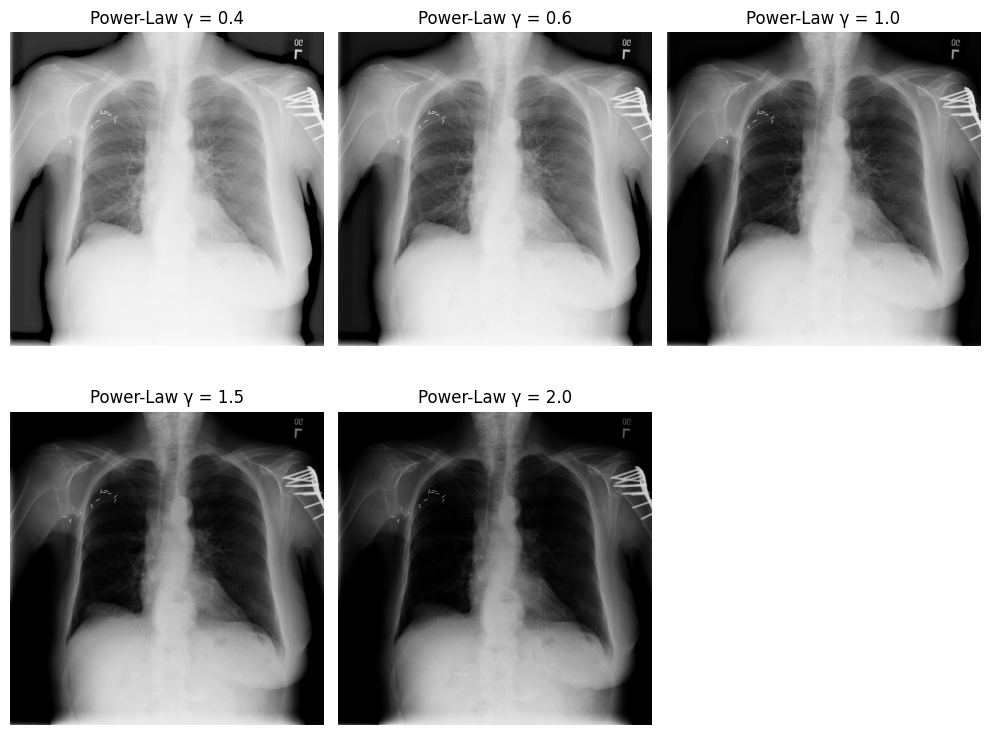

In [19]:
plt.figure(figsize=(10, 8))

for i, gamma in enumerate(gamma_values):

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        power_images[gamma],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    plt.title(f"Power-Law γ = {gamma}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Histograms for All Gamma Values

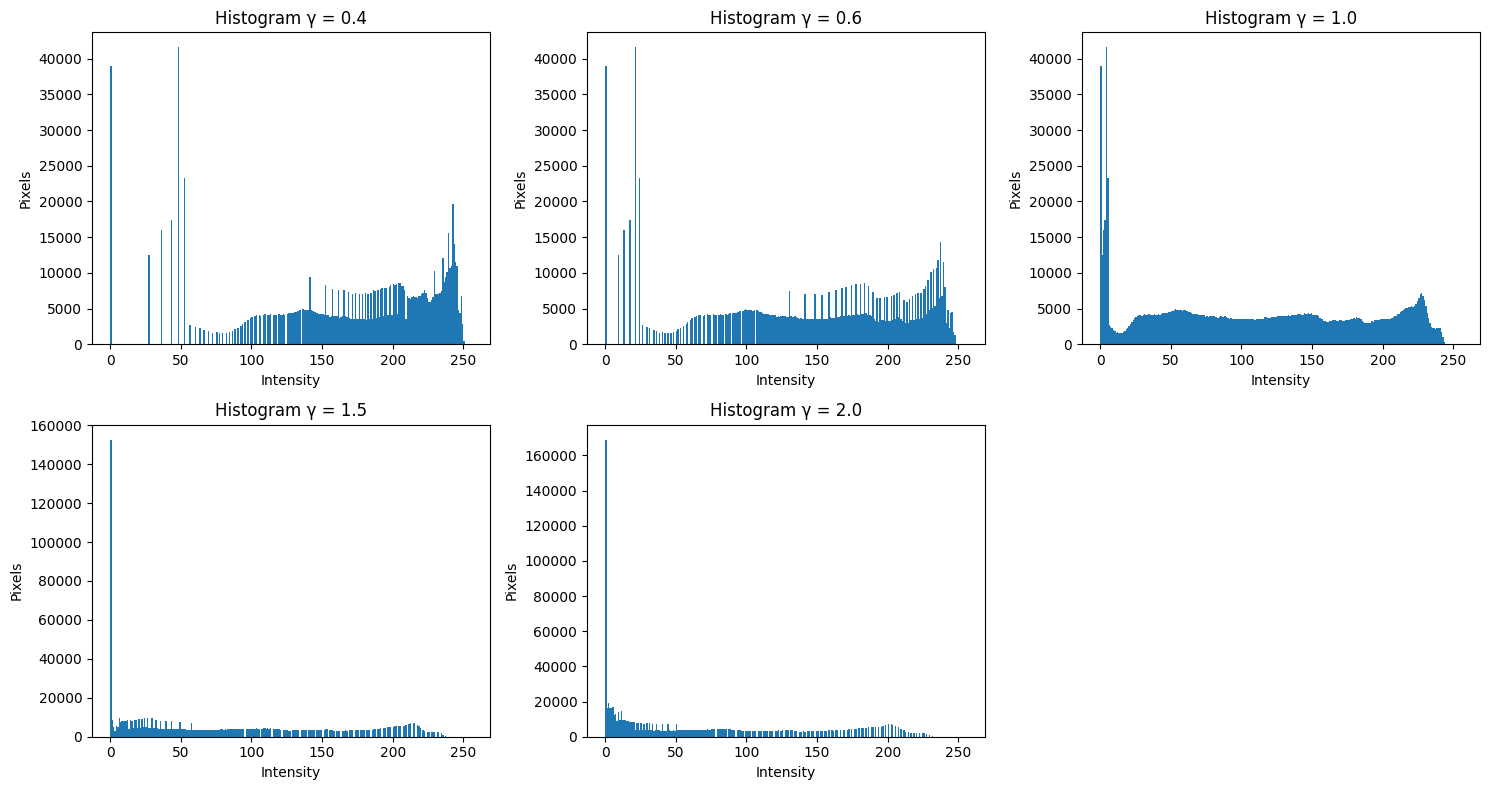

In [20]:
plt.figure(figsize=(15, 8))

for i, gamma in enumerate(gamma_values):

    plt.subplot(2, 3, i + 1)

    plt.hist(
        power_images[gamma].ravel(),
        bins=256,
        range=(0, 256)
    )

    plt.title(f"Histogram γ = {gamma}")
    plt.xlabel("Intensity")
    plt.ylabel("Pixels")

plt.tight_layout()
plt.show()

# Inverse Logarithmic / Exponential Transformation

From the graph, the inverse logarithmic transformation can be represented as:

$$ s=e^{cr}-1 $$

For normalized output [0,1], use:

$$ s=\frac{e^r-1}{e-1} $$

This transformation emphasizes the higher-intensity range and generally darkens lower/mid-level pixels relative to the identity mapping.

In [21]:
# ============================================================
# Inverse Logarithmic / Exponential Transformation
# s = (e^r - 1) / (e - 1)
# ============================================================

inverse_log_image = (
    np.exp(normalized_image) - 1
) / (
    np.e - 1
)

inverse_log_image_uint8 = np.clip(
    inverse_log_image * 255,
    0,
    255
).astype(np.uint8)

print("Inverse-logarithmic transformation completed.")

Inverse-logarithmic transformation completed.


Display Inverse-Log Image

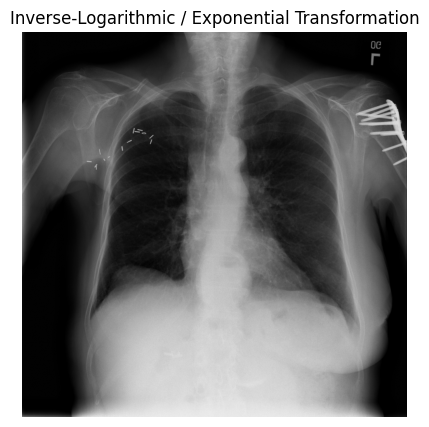

In [23]:
plt.figure(figsize=(8, 5))

plt.imshow(
    inverse_log_image_uint8,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("Inverse-Logarithmic / Exponential Transformation")
plt.axis("off")

plt.show()

Inverse-Log Histogram

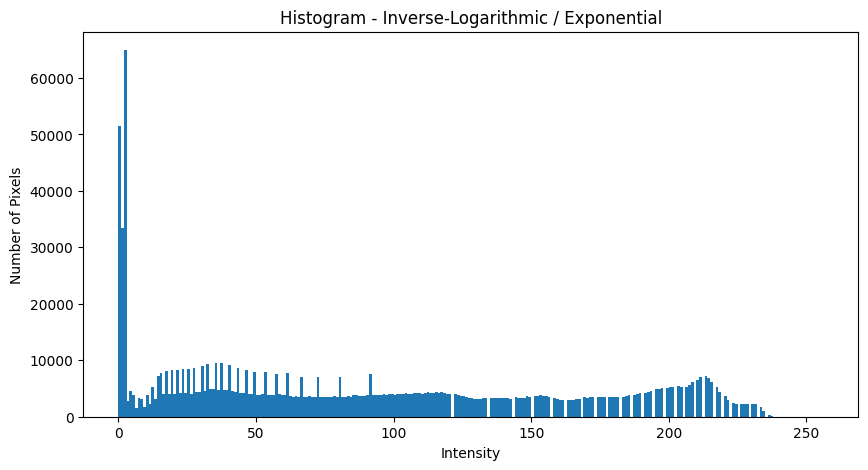

In [24]:
plt.figure(figsize=(10, 5))

plt.hist(
    inverse_log_image_uint8.ravel(),
    bins=256,
    range=(0, 256)
)

plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Histogram - Inverse-Logarithmic / Exponential")

plt.show()

# Comapre All Transformations Together
    Original + Log + Gamma Transformations + Exponential

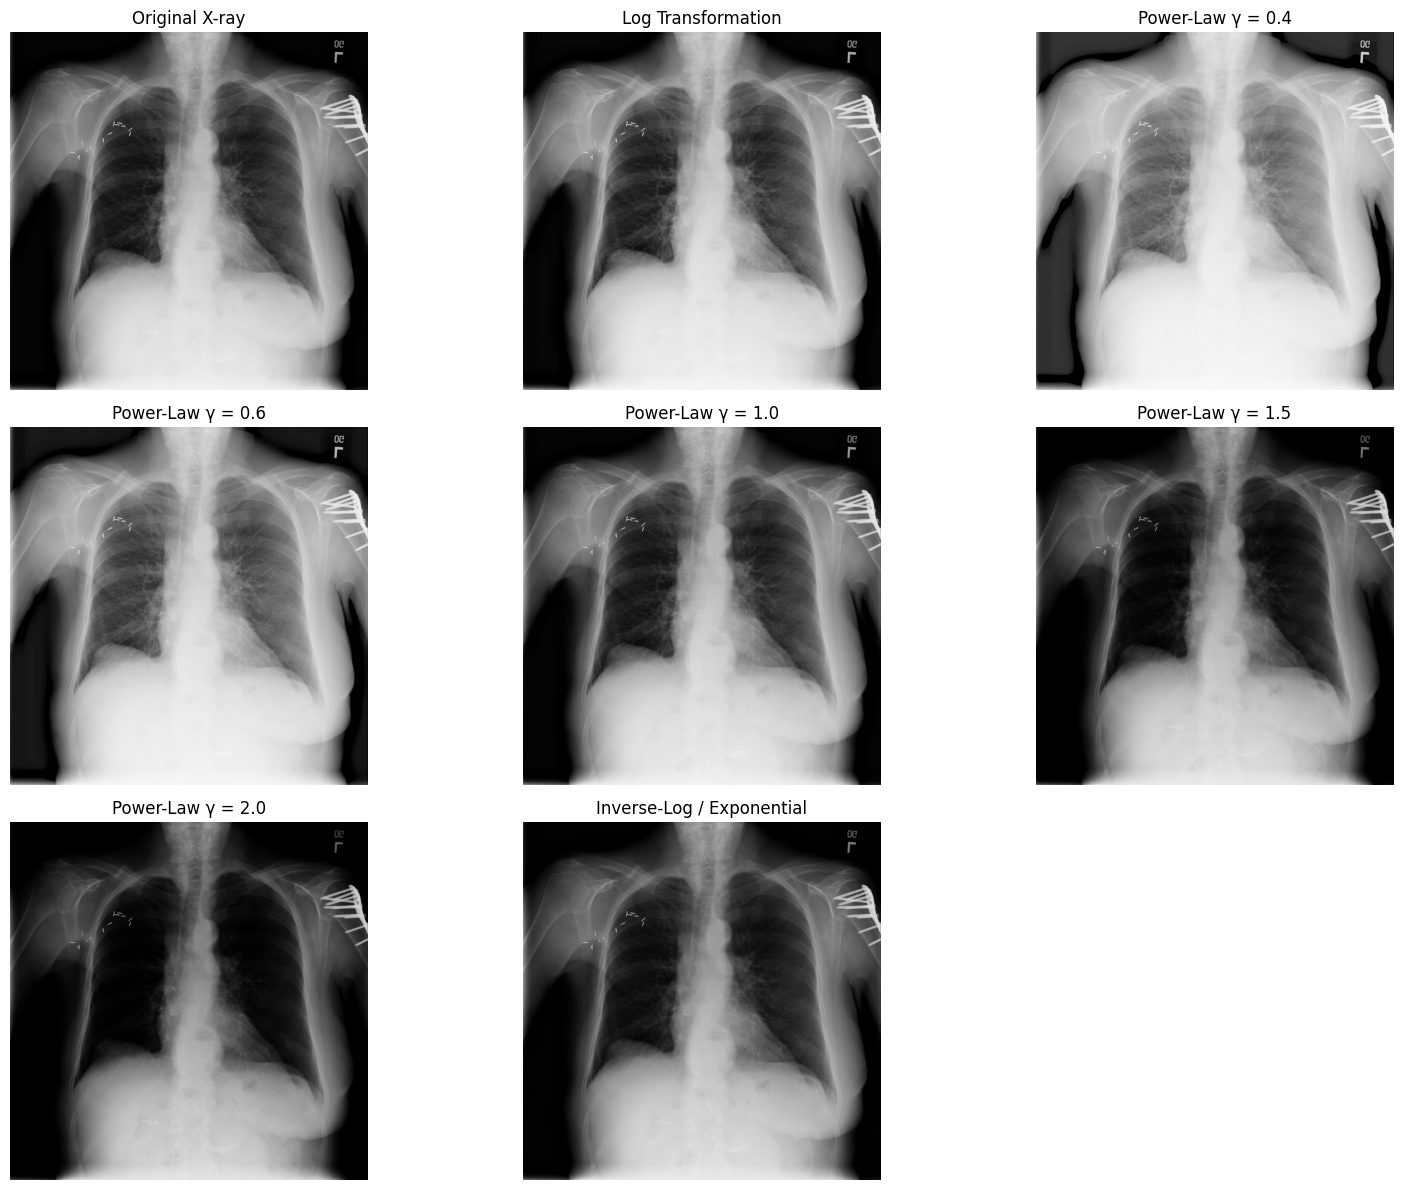

In [25]:
plt.figure(figsize=(16, 12))

# Original
plt.subplot(3, 3, 1)

plt.imshow(
    gray_image,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("Original X-ray")
plt.axis("off")


# Log
plt.subplot(3, 3, 2)

plt.imshow(
    log_image_uint8,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("Log Transformation")
plt.axis("off")


# Gamma transformations
for i, gamma in enumerate(gamma_values):

    plt.subplot(3, 3, i + 3)

    plt.imshow(
        power_images[gamma],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    plt.title(f"Power-Law γ = {gamma}")
    plt.axis("off")


# Exponential
plt.subplot(3, 3, 8)

plt.imshow(
    inverse_log_image_uint8,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("Inverse-Log / Exponential")
plt.axis("off")

plt.tight_layout()
plt.show()

# Comparison

# Calculate Quantitative Results


In [26]:
# ============================================================
# Quantitative comparison
# ============================================================

transformation_images = {
    "Original": gray_image,
    "Log": log_image_uint8,
    "Gamma 0.4": power_images[0.4],
    "Gamma 0.6": power_images[0.6],
    "Gamma 1.0": power_images[1.0],
    "Gamma 1.5": power_images[1.5],
    "Gamma 2.0": power_images[2.0],
    "Inverse Log": inverse_log_image_uint8
}

comparison_data = []

for name, img in transformation_images.items():

    comparison_data.append({
        "Transformation": name,
        "Minimum": np.min(img),
        "Maximum": np.max(img),
        "Mean": np.mean(img),
        "Standard Deviation": np.std(img)
    })

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Transformation,Minimum,Maximum,Mean,Standard Deviation
0,Original,0,248,108.643370,75.853136
1,Log,0,249,121.872576,78.090759
2,Gamma 0.4,0,252,162.072825,68.742948
3,Gamma 0.6,0,250,139.051841,73.763255
4,Gamma 1.0,0,248,108.643370,75.853136
5,Gamma 1.5,0,244,84.186023,73.451716
6,Gamma 2.0,0,241,68.454743,69.583312
7,Inverse Log,0,244,88.625702,70.950928


Compare Mean Brightness

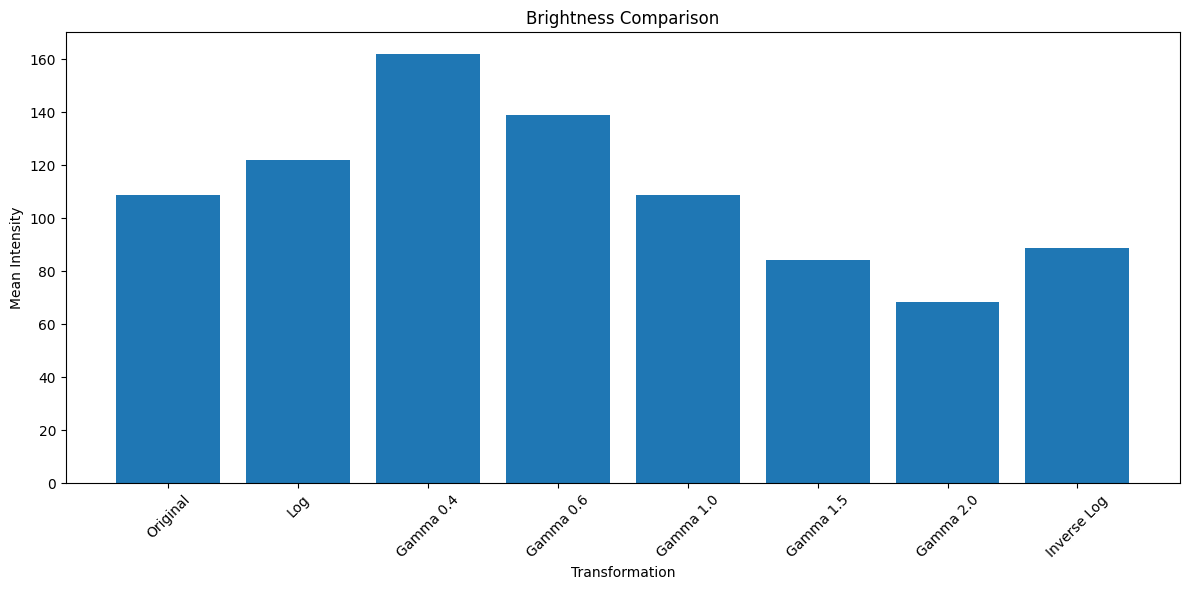

In [27]:
plt.figure(figsize=(12, 6))

plt.bar(
    comparison_df["Transformation"],
    comparison_df["Mean"]
)

plt.xlabel("Transformation")
plt.ylabel("Mean Intensity")
plt.title("Brightness Comparison")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Compare Contrast

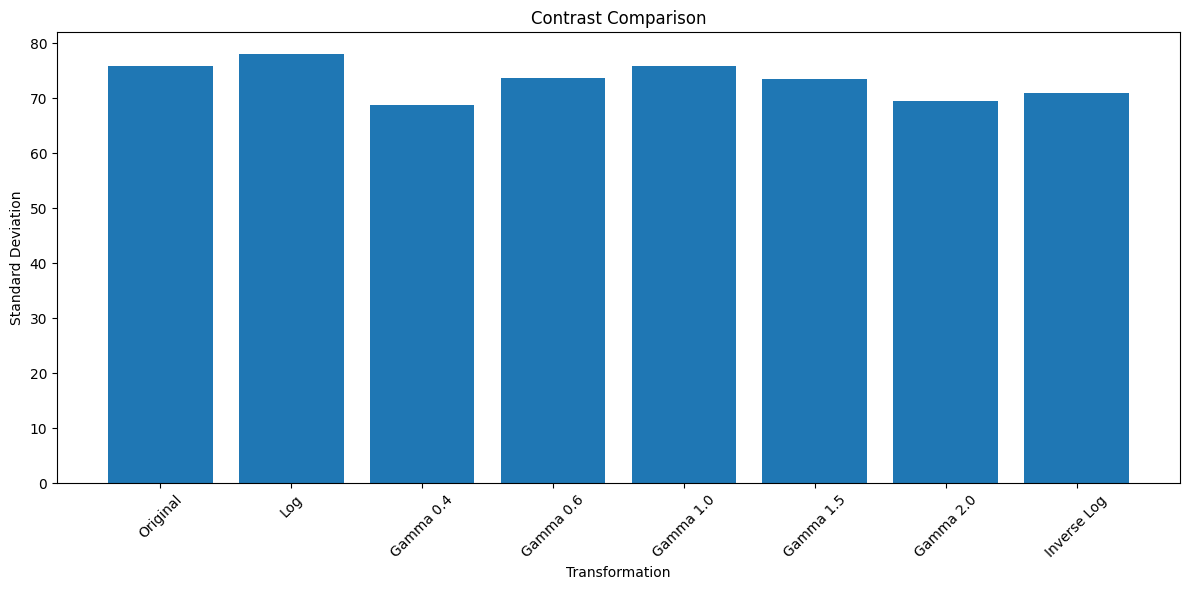

In [28]:
plt.figure(figsize=(12, 6))

plt.bar(
    comparison_df["Transformation"],
    comparison_df["Standard Deviation"]
)

plt.xlabel("Transformation")
plt.ylabel("Standard Deviation")
plt.title("Contrast Comparison")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Complete Histogram Comparison

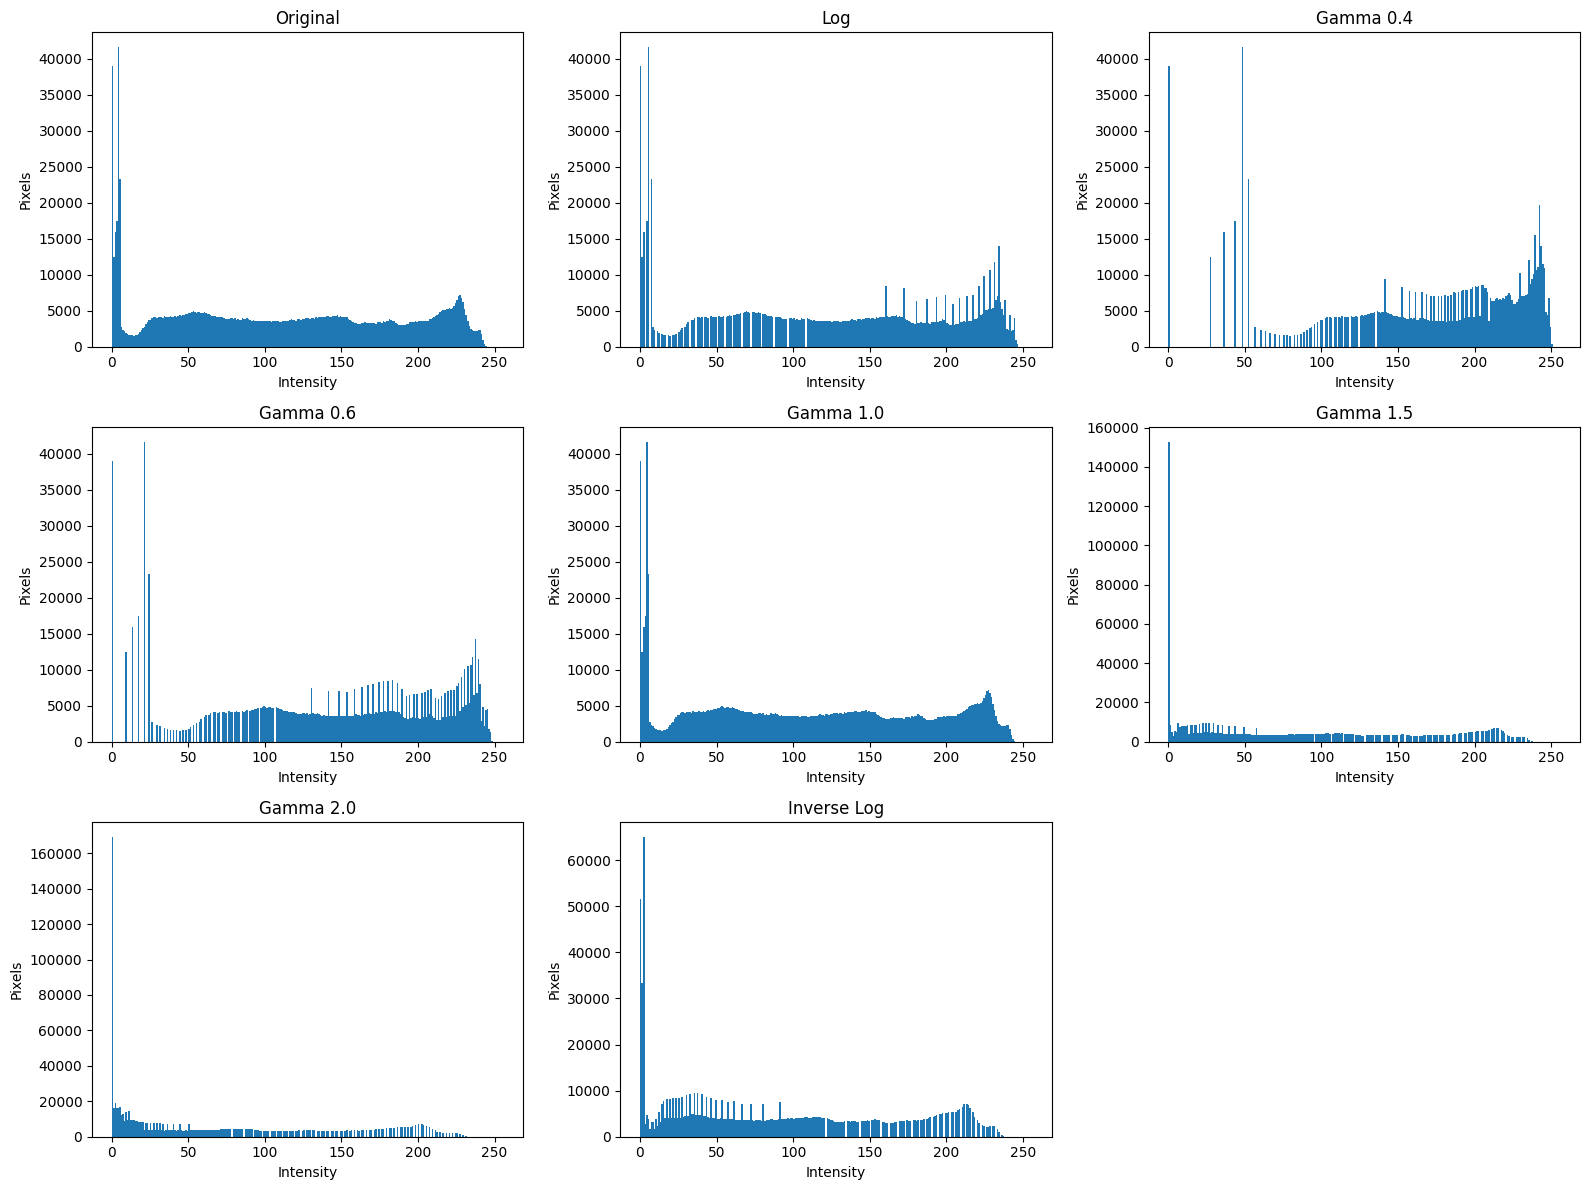

In [29]:
plt.figure(figsize=(16, 12))

for i, (name, img) in enumerate(transformation_images.items()):

    plt.subplot(3, 3, i + 1)

    plt.hist(
        img.ravel(),
        bins=256,
        range=(0, 256)
    )

    plt.title(name)
    plt.xlabel("Intensity")
    plt.ylabel("Pixels")

plt.tight_layout()
plt.show()

Automatically Identify Brightest / Highest Contrast

    Quantitative Summary

In [30]:
brightest = comparison_df.loc[
    comparison_df["Mean"].idxmax()
]

highest_contrast = comparison_df.loc[
    comparison_df["Standard Deviation"].idxmax()
]

print("Brightest transformation:")
print(brightest)

print()

print("Highest standard deviation / contrast:")
print(highest_contrast)

Brightest transformation:
Transformation         Gamma 0.4
Minimum                        0
Maximum                      252
Mean                  162.072825
Standard Deviation     68.742948
Name: 2, dtype: object

Highest standard deviation / contrast:
Transformation               Log
Minimum                        0
Maximum                      249
Mean                  121.872576
Standard Deviation     78.090759
Name: 1, dtype: object


Dark Region Visibility

    Dark-Pixel Distribution

In [31]:
# ============================================================
# Dark-region visibility analysis
# ============================================================

dark_thresholds = [50, 75, 100]

dark_region_results = []

for name, img in transformation_images.items():

    result = {
        "Transformation": name
    }

    for threshold in dark_thresholds:

        percentage = (
            np.sum(img < threshold)
            / img.size
            * 100
        )

        result[f"< {threshold}"] = percentage

    dark_region_results.append(result)

dark_region_df = pd.DataFrame(
    dark_region_results
)

dark_region_df

,Transformation,< 50,< 75,< 100
0,Original,28.340816,39.025784,47.951698
1,Log,23.405170,31.990433,40.889168
2,Gamma 0.4,12.062740,15.503502,18.357944
3,Gamma 0.6,16.274834,21.823215,30.164623
4,Gamma 1.0,28.340816,39.025784,47.951698
5,Gamma 1.5,43.437290,52.320099,61.130905
6,Gamma 2.0,52.320099,61.910629,69.944000
7,Inverse Log,39.025784,49.634171,59.208775


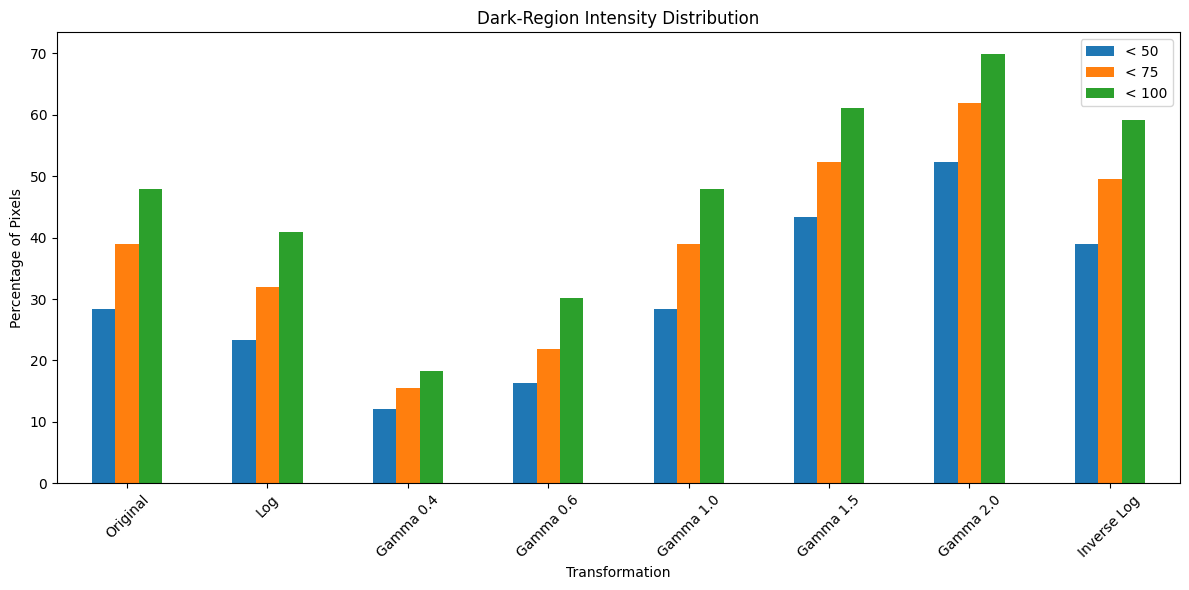

In [32]:
dark_region_df.set_index(
    "Transformation"
).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Transformation")
plt.ylabel("Percentage of Pixels")
plt.title("Dark-Region Intensity Distribution")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Best Transformation

  Display Candidate Enhancements

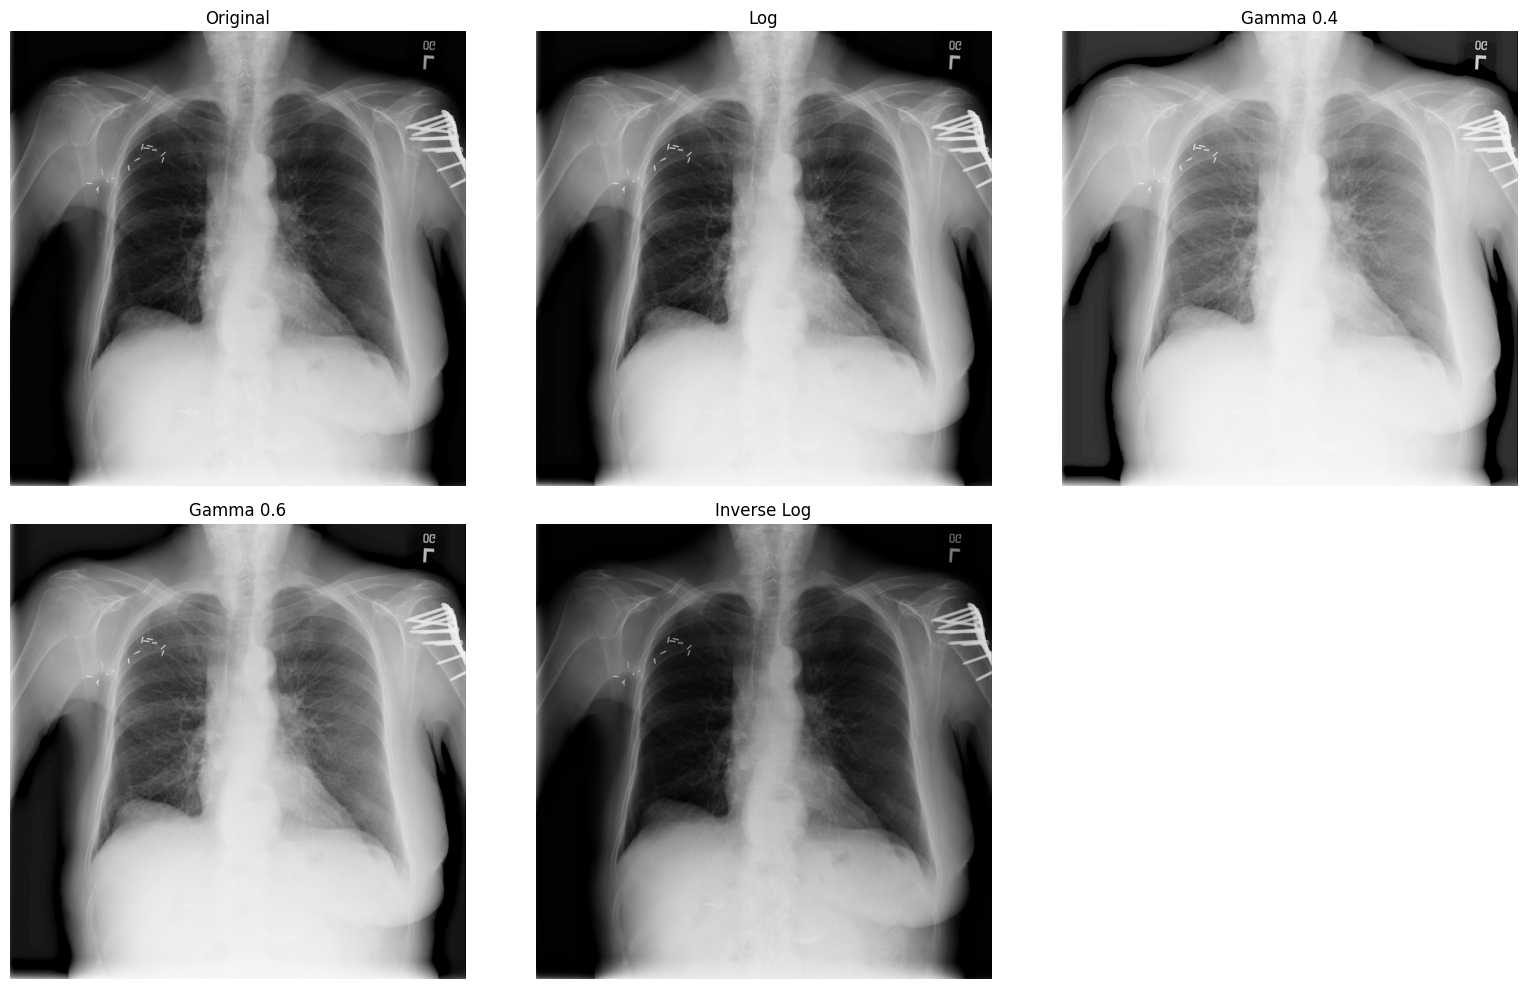

In [33]:
candidate_names = [
    "Original",
    "Log",
    "Gamma 0.4",
    "Gamma 0.6",
    "Inverse Log"
]

plt.figure(figsize=(16, 10))

for i, name in enumerate(candidate_names):

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        transformation_images[name],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

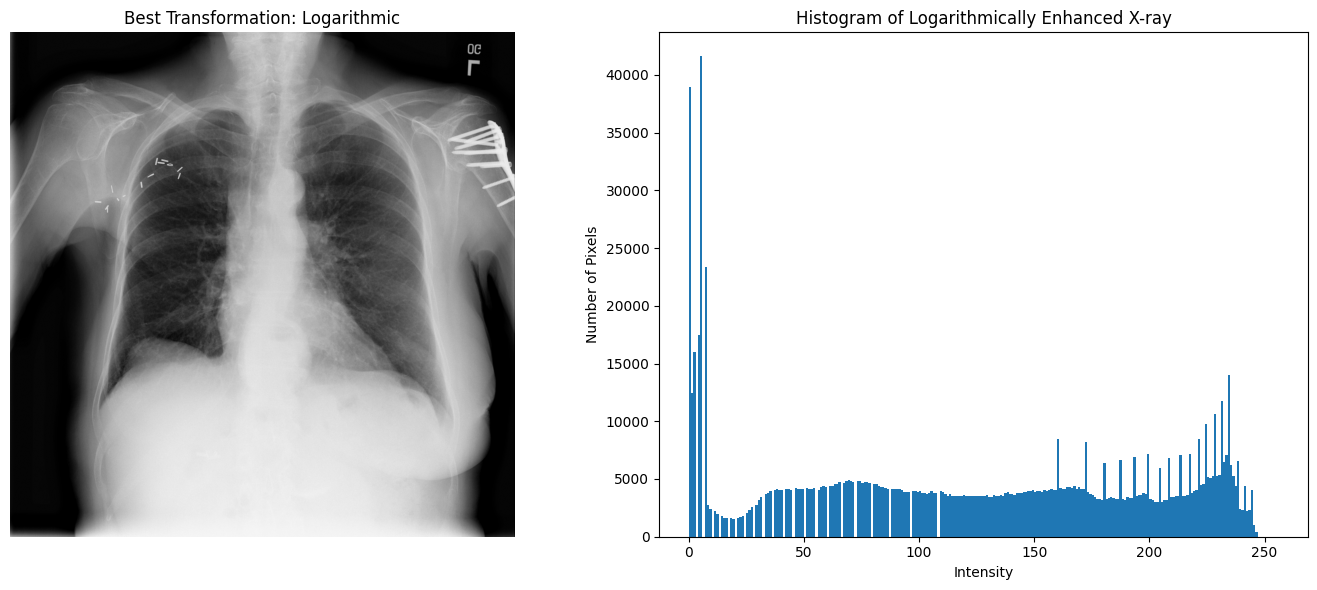

In [34]:
best_image = log_image_uint8

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)

plt.imshow(
    best_image,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("Best Transformation: Logarithmic")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.hist(
    best_image.ravel(),
    bins=256,
    range=(0, 256)
)

plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Histogram of Logarithmically Enhanced X-ray")

plt.tight_layout()
plt.show()

In [35]:
final_summary = pd.DataFrame({
    "Requirement": [
        "Original Image",
        "Logarithmic Transformation",
        "Power-Law γ = 0.4",
        "Power-Law γ = 0.6",
        "Power-Law γ = 1.0",
        "Power-Law γ = 1.5",
        "Power-Law γ = 2.0",
        "Inverse-Logarithmic Transformation"
    ],

    "Implemented Manually": [
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True
    ]
})

final_summary

,Requirement,Implemented Manually
0,Original Image,True
1,Logarithmic Transformation,True
2,Power-Law γ = 0.4,True
3,Power-Law γ = 0.6,True
4,Power-Law γ = 1.0,True
5,Power-Law γ = 1.5,True
6,Power-Law γ = 2.0,True
7,Inverse-Logarithmic Transformation,True
